## Implementing GMM-EM from scratch (to learn)

### Imports

In [7]:
import numpy as np
from scipy.stats import multivariate_normal

### Gaussian Implementation

In [8]:
class GMM:
    def __init__(self, n_components, n_iter=100, tol=1e-6, reg_covar=1e-6, random_state=None):
        self.K = n_components # How many clusters to find
        self.n_iter = n_iter # Number of iterations to run the EM algorithm
        self.tol = tol  # Early stop when improvement deminishes 
        self.reg_covar = reg_covar # # Regularization term to avoid singular covariance matrices
        self.rng = np.random.default_rng(random_state) # RNG

    def _init_params(self, X):
        n, d = X.shape # Read rows and numbers
        idx = self.rng.choice(n, self.K, replace=False) # Randomly select K data points as initial means
        self.means_ = X[idx].copy() # Set the means to the selected data points
        self.covariances_ = np.array([np.cov(X.T) + self.reg_covar * np.eye(d) for _ in range(self.K)]) # Initial covariances as the covariance of the data plus regularization
        self.weights_ = np.full(self.K, 1.0 / self.K) # Initial weights as uniform distribution

    def _e_step(self, X):
        n = X.shape[0]
        resp = np.zeros((n, self.K)) # Initialize responsibilities matrix
        for k in range(self.K):
            resp[:, k] = self.weights_[k] * multivariate_normal.pdf(
                    X, mean=self.means_[k], cov=self.covariances_[k], allow_singular=True
                ) # Compute the responsibilities for each component
        total = resp.sum(axis=1, keepdims=True) # Get total probabilty, summed over all clusters
        total[total == 0] = 1e-300 # avoid division by zero
        resp /= total # Normalize responsibilities
        log_likelihood = np.sum(np.log(total.flatten() + 1e-300)) # Compute log likelihood
        return resp, log_likelihood

    def _m_step(self, X, resp):
        n, d = X.shape
        Nk = resp.sum(axis=0) # Effective number of points assigned to each cluster
        Nk = np.maximum(Nk, 1e-300) # Avoid division by zero
        self.weights_ = Nk / n # Update weights
        self.means_ = (resp.T @ X) / Nk[:, None] # Update center to be weighted average of points assigned to each cluster
        covariances = []
        for k in range(self.K):
            diff = X - self.means_[k] # distance between new center and points
            weighted = resp[:, k, None] * diff # Weighted distance dependent on responsibility for the cluster's center
            cov_k = (weighted.T @ diff) / Nk[k] # Compute covariance for cluster k
            cov_k += self.reg_covar * np.eye(d) # Add regularization term to avoid singular covariance matrices
            covariances.append(cov_k) # Append to list of covariances
        self.covariances_ = np.array(covariances) # Update covariances

    def fit(self, X):
        self._init_params(X) # Initialize parameters
        prev_ll = -np.inf # Previous log likelihood
        self.log_likelihoods_ = [] # List to store log likelihoods for each iteration
        for i in range(self.n_iter):
            resp, ll = self._e_step(X) # E-step: compute responsibilities and log likelihood
            self._m_step(X, resp) # M-step: update parameters based on responsibilities
            self.log_likelihoods_.append(ll) # Store log likelihood
            if abs(ll - prev_ll) < self.tol: # Check for convergence
                break
            prev_ll = ll # Update previous log likelihood
        return self

    def predict_proba(self, X):
        resp, _ = self._e_step(X) # Using e-step to compute responsibilities for new data points
        return resp

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1) # Assign each point to the cluster with the highest responsibility

    


## Testing


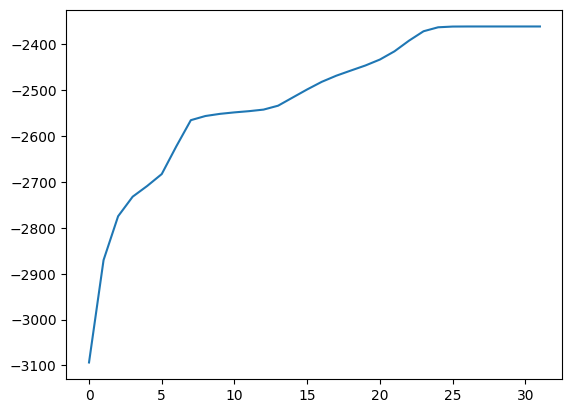

[[ 6.03972848  6.01400035]
 [-0.02755871 -0.08548093]
 [-0.06274027  5.87948794]]


In [9]:
import matplotlib.pyplot as plt

X = np.vstack([
    np.random.randn(200, 2) + [0, 0],
    np.random.randn(200, 2) + [6, 6],
    np.random.randn(200, 2) + [0, 6],
])
gmm = GMM(n_components=3, random_state=0).fit(X)
plt.plot(gmm.log_likelihoods_)
plt.show()
print(gmm.means_)   # should land near [0,0], [6,6], [0,6]

In [10]:
# Comparison against sklearn
from sklearn.mixture import GaussianMixture
sk = GaussianMixture(n_components=3, random_state=0).fit(X)
print(sk.means_)

[[ 6.03973503  6.01399977]
 [-0.06279653  5.88022813]
 [-0.02749965 -0.08489188]]


/Users/arqies/Documents/Githubs/Spam-Classifier/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arqies/Documents/Githubs/Spam-Classifier/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arqies/Documents/Githubs/Spam-Classifier/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Quite Close, so success?